In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv("energydata_complete.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (19735, 29)


In [3]:
print(df.head())

                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4  2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
4  19.79  45.000000  18.890000  ...  17.000000  45.40  6.133333        733.9   

   RH_out  Windspeed  Visibility

In [4]:
print(df.tail())

                      date  Appliances  lights         T1       RH_1  \
19730  2016-05-27 17:20:00         100       0  25.566667  46.560000   
19731  2016-05-27 17:30:00          90       0  25.500000  46.500000   
19732  2016-05-27 17:40:00         270      10  25.500000  46.596667   
19733  2016-05-27 17:50:00         420      10  25.500000  46.990000   
19734  2016-05-27 18:00:00         430      10  25.500000  46.600000   

              T2       RH_2         T3       RH_3    T4  ...    T9     RH_9  \
19730  25.890000  42.025714  27.200000  41.163333  24.7  ...  23.2  46.7900   
19731  25.754000  42.080000  27.133333  41.223333  24.7  ...  23.2  46.7900   
19732  25.628571  42.768571  27.050000  41.690000  24.7  ...  23.2  46.7900   
19733  25.414000  43.036000  26.890000  41.290000  24.7  ...  23.2  46.8175   
19734  25.264286  42.971429  26.823333  41.156667  24.7  ...  23.2  46.8450   

           T_out  Press_mm_hg     RH_out  Windspeed  Visibility  Tdewpoint  \
19730  22.7333

In [5]:
print("Columns:")
for column in df.columns:
    print(column)

Columns:
date
Appliances
lights
T1
RH_1
T2
RH_2
T3
RH_3
T4
RH_4
T5
RH_5
T6
RH_6
T7
RH_7
T8
RH_8
T9
RH_9
T_out
Press_mm_hg
RH_out
Windspeed
Visibility
Tdewpoint
rv1
rv2


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

In [7]:
print(df.describe())

         Appliances        lights            T1          RH_1            T2  \
count  19735.000000  19735.000000  19735.000000  19735.000000  19735.000000   
mean      97.694958      3.801875     21.686571     40.259739     20.341219   
std      102.524891      7.935988      1.606066      3.979299      2.192974   
min       10.000000      0.000000     16.790000     27.023333     16.100000   
25%       50.000000      0.000000     20.760000     37.333333     18.790000   
50%       60.000000      0.000000     21.600000     39.656667     20.000000   
75%      100.000000      0.000000     22.600000     43.066667     21.500000   
max     1080.000000     70.000000     26.260000     63.360000     29.856667   

               RH_2            T3          RH_3            T4          RH_4  \
count  19735.000000  19735.000000  19735.000000  19735.000000  19735.000000   
mean      40.420420     22.267611     39.242500     20.855335     39.026904   
std        4.069813      2.006111      3.254576    

In [8]:
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values)

Missing values:
date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64


In [9]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [10]:
df["date"] = pd.to_datetime(df["date"])

print(df["date"].dtype)

datetime64[us]


In [11]:
# Create Time Features

In [12]:
df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

print(df[[
    "date",
    "hour",
    "day",
    "month",
    "day_of_week"
]].head())

                 date  hour  day  month  day_of_week
0 2016-01-11 17:00:00    17   11      1            0
1 2016-01-11 17:10:00    17   11      1            0
2 2016-01-11 17:20:00    17   11      1            0
3 2016-01-11 17:30:00    17   11      1            0
4 2016-01-11 17:40:00    17   11      1            0


In [13]:
# Create Weekend Feature

In [14]:
df["is_weekend"] = df["day_of_week"].apply(
    lambda x: 1 if x >= 5 else 0
)

print(df[[
    "date",
    "day_of_week",
    "is_weekend"
]].head())

                 date  day_of_week  is_weekend
0 2016-01-11 17:00:00            0           0
1 2016-01-11 17:10:00            0           0
2 2016-01-11 17:20:00            0           0
3 2016-01-11 17:30:00            0           0
4 2016-01-11 17:40:00            0           0


In [15]:
# Create Evening Feature

In [16]:
df["is_evening"] = df["hour"].apply(
    lambda x: 1 if x >= 18 else 0
)

print(df[[
    "hour",
    "is_evening"
]].head(10))

   hour  is_evening
0    17           0
1    17           0
2    17           0
3    17           0
4    17           0
5    17           0
6    18           1
7    18           1
8    18           1
9    18           1


In [17]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 19735
Columns: 35


In [18]:
# Appliance Consumption Distribution

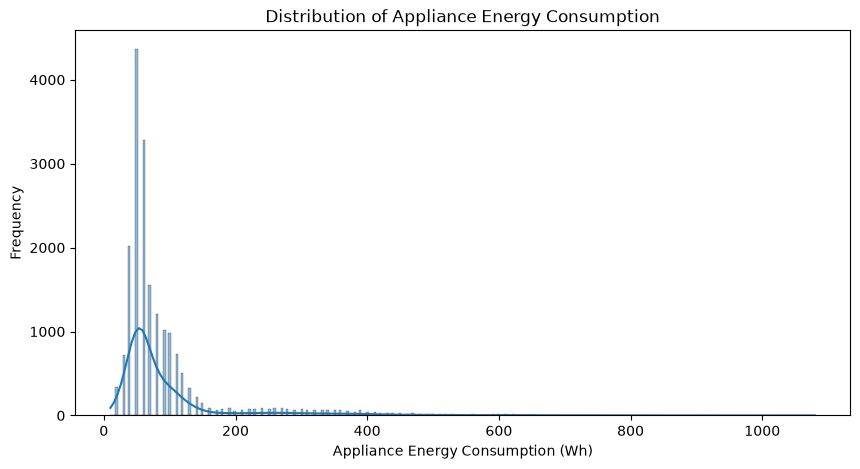

In [19]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Appliances",
    kde=True
)

plt.title("Distribution of Appliance Energy Consumption")
plt.xlabel("Appliance Energy Consumption (Wh)")
plt.ylabel("Frequency")

plt.show()

In [20]:
# Boxplot — Find Outliers

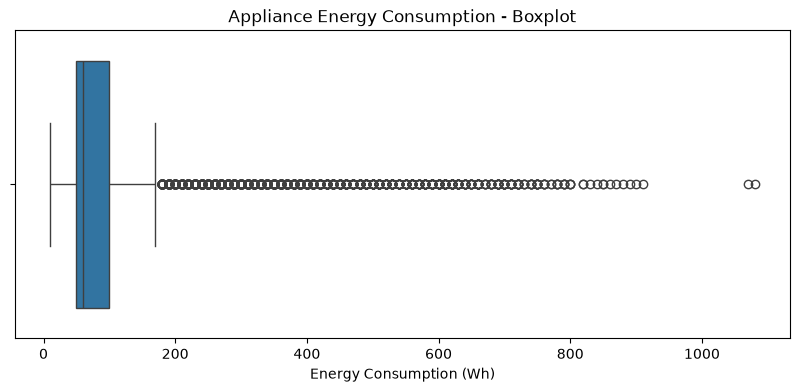

In [21]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df["Appliances"]
)

plt.title("Appliance Energy Consumption - Boxplot")
plt.xlabel("Energy Consumption (Wh)")

plt.show()

In [22]:
# Energy Consumption Over Time

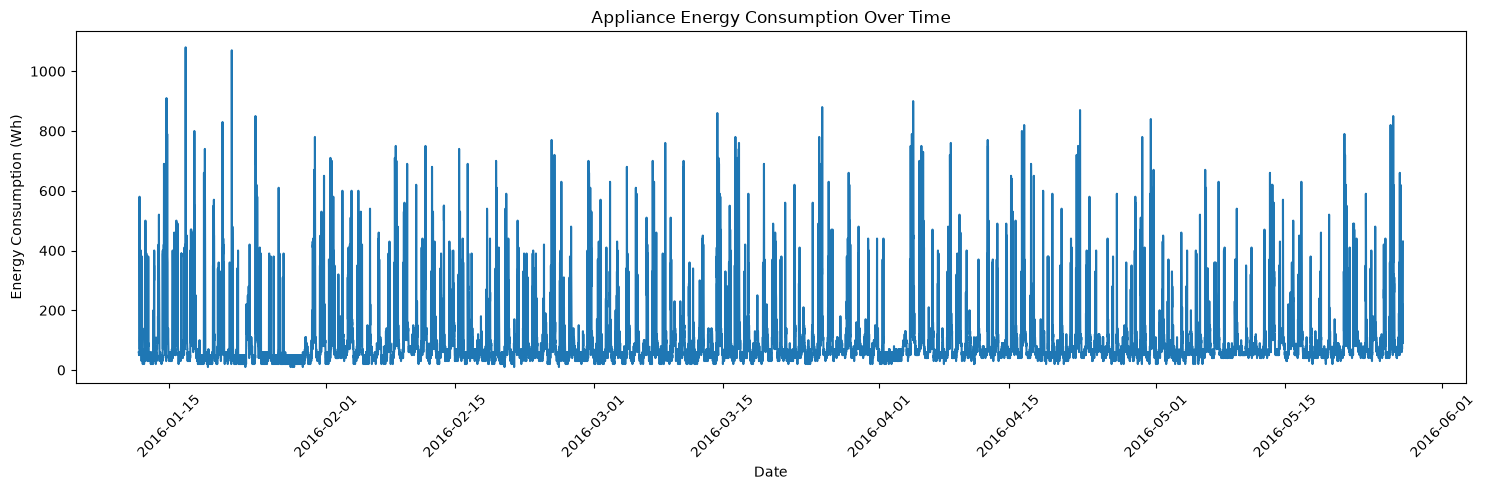

In [23]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["date"],
    df["Appliances"]
)

plt.title("Appliance Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (Wh)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
# Average Consumption by Hour

In [25]:
hourly_energy = df.groupby(
    "hour"
)["Appliances"].mean()

print(hourly_energy)

hour
0      52.785888
1      51.326034
2      49.075426
3      48.236010
4      49.355231
5      52.737226
6      57.712895
7      78.649635
8     106.143552
9     112.785888
10    125.377129
11    133.126521
12    123.637470
13    124.744526
14    108.284672
15    105.827251
16    119.902676
17    161.352657
18    190.364520
19    143.065693
20    126.982968
21     96.496350
22     69.148418
23     56.982968
Name: Appliances, dtype: float64


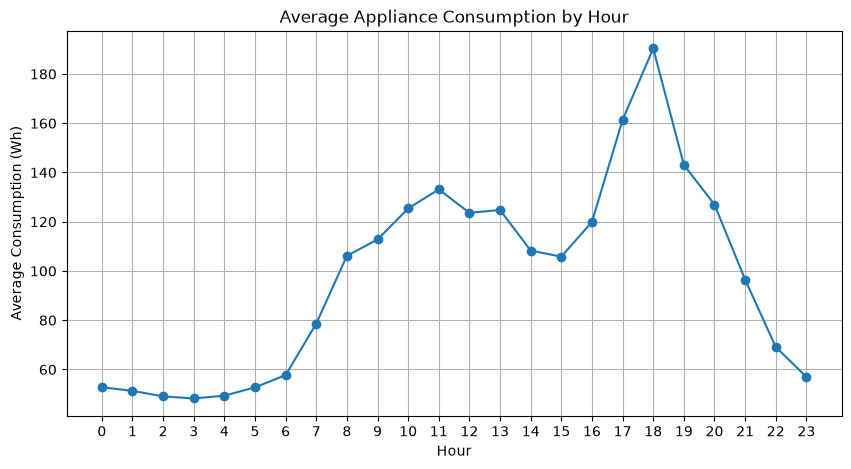

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_energy.index,
    hourly_energy.values,
    marker="o"
)

plt.title("Average Appliance Consumption by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Consumption (Wh)")

plt.xticks(range(24))

plt.grid(True)

plt.show()

In [27]:
## Weekend vs Weekday

In [28]:
weekend_energy = df.groupby(
    "is_weekend"
)["Appliances"].mean()

print(weekend_energy)

is_weekend
0     96.587674
1    100.581140
Name: Appliances, dtype: float64


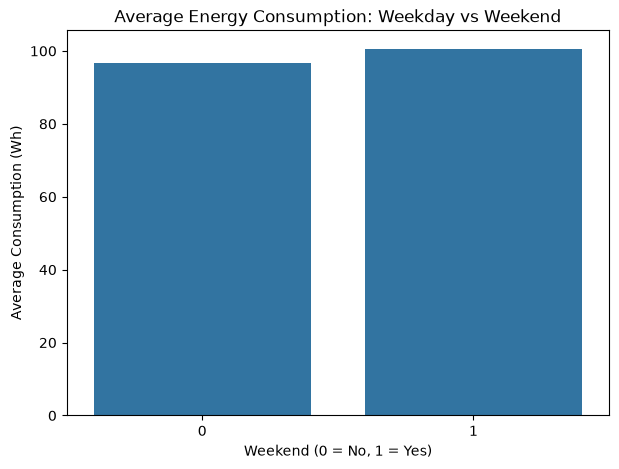

In [29]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=weekend_energy.index,
    y=weekend_energy.values
)

plt.title("Average Energy Consumption: Weekday vs Weekend")
plt.xlabel("Weekend (0 = No, 1 = Yes)")
plt.ylabel("Average Consumption (Wh)")

plt.show()

In [30]:
# Outdoor Temperature vs Energy

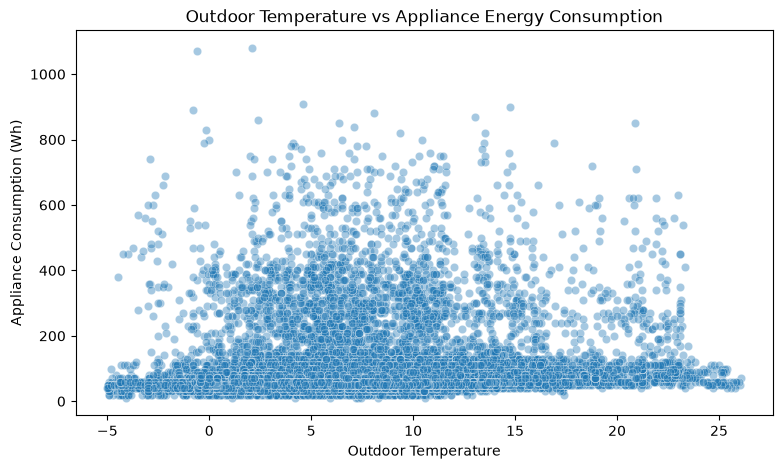

In [31]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="T_out",
    y="Appliances",
    alpha=0.4
)

plt.title("Outdoor Temperature vs Appliance Energy Consumption")
plt.xlabel("Outdoor Temperature")
plt.ylabel("Appliance Consumption (Wh)")

plt.show()

In [32]:
# Correlation Matrix

In [33]:
correlation = df.corr(numeric_only=True)

print(correlation["Appliances"].sort_values(
    ascending=False
))

Appliances     1.000000
hour           0.216792
lights         0.197278
T2             0.120073
T6             0.117638
T_out          0.099155
is_evening     0.090999
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
T1             0.055447
T4             0.040281
T8             0.039572
RH_3           0.036292
T7             0.025801
T5             0.019760
is_weekend     0.017437
RH_4           0.016965
Tdewpoint      0.015353
T9             0.010010
RH_5           0.006955
day_of_week    0.003060
day            0.002366
Visibility     0.000230
rv1           -0.011145
rv2           -0.011145
month         -0.011606
Press_mm_hg   -0.034885
RH_9          -0.051462
RH_7          -0.055642
RH_2          -0.060465
RH_6          -0.083178
RH_8          -0.094039
RH_out        -0.152282
Name: Appliances, dtype: float64


In [34]:
# Correlation Heatmap

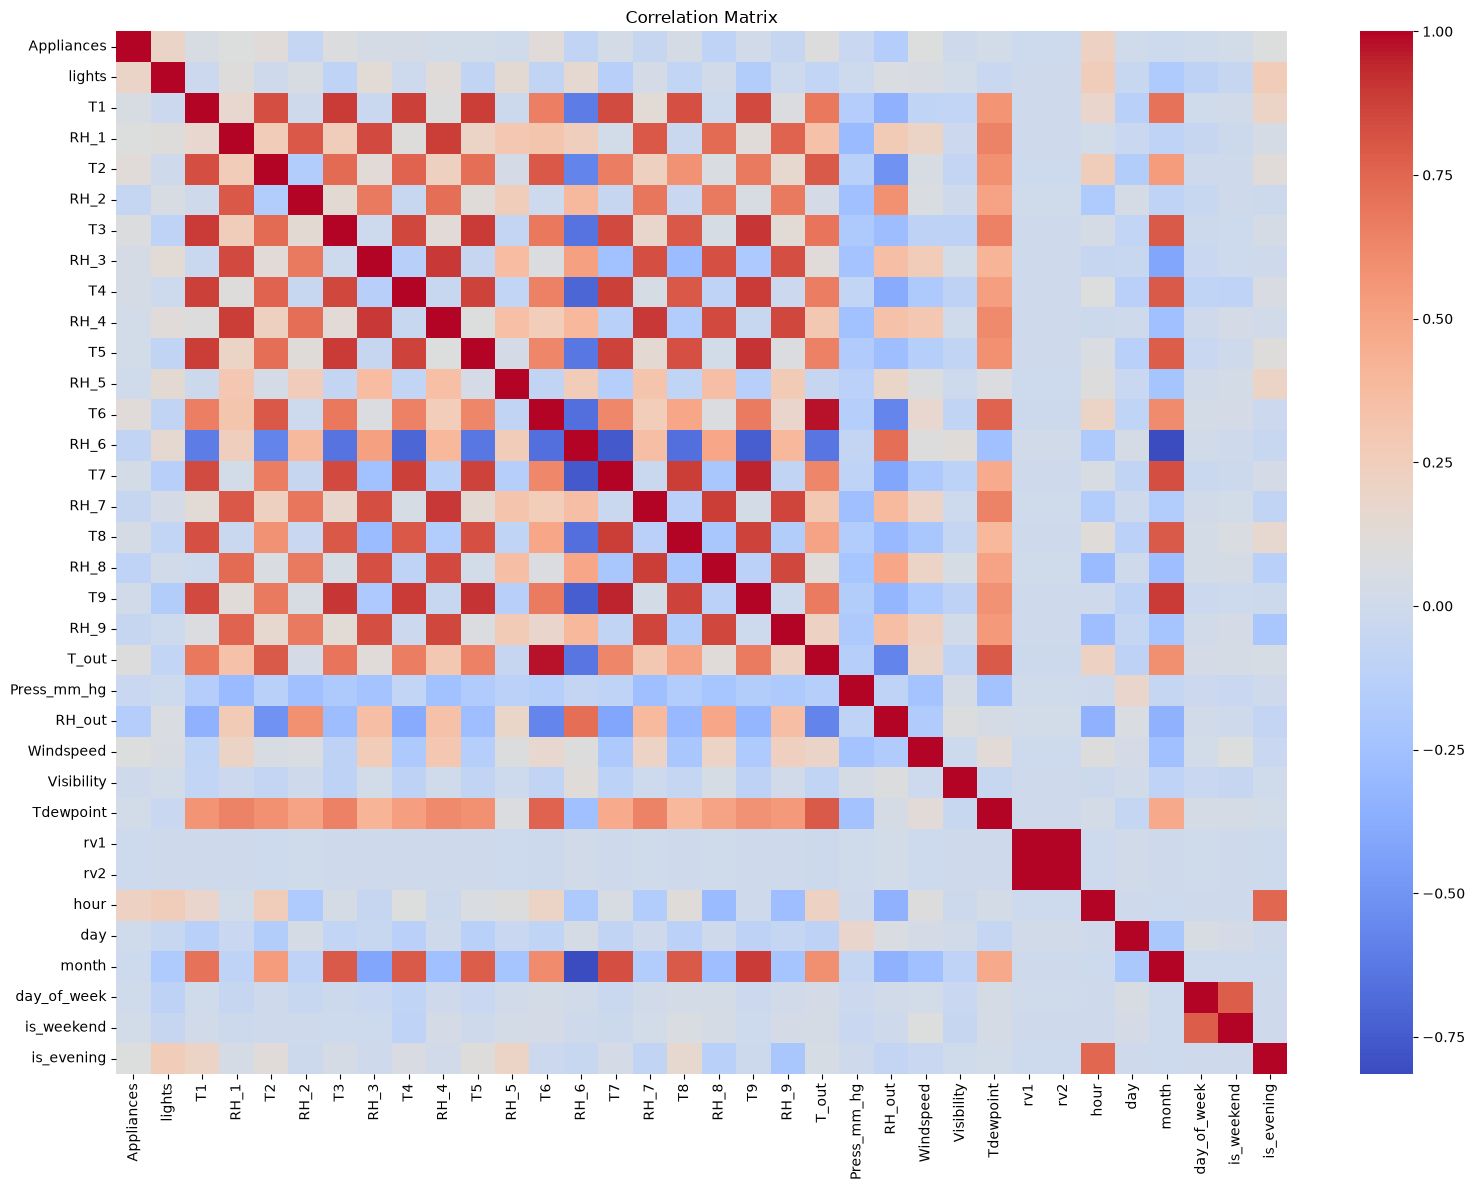

In [35]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    annot=False,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [36]:
# Top Correlations With Target

In [37]:
target_correlation = (
    correlation["Appliances"]
    .sort_values(ascending=False)
)

print(target_correlation)

Appliances     1.000000
hour           0.216792
lights         0.197278
T2             0.120073
T6             0.117638
T_out          0.099155
is_evening     0.090999
Windspeed      0.087122
RH_1           0.086031
T3             0.085060
T1             0.055447
T4             0.040281
T8             0.039572
RH_3           0.036292
T7             0.025801
T5             0.019760
is_weekend     0.017437
RH_4           0.016965
Tdewpoint      0.015353
T9             0.010010
RH_5           0.006955
day_of_week    0.003060
day            0.002366
Visibility     0.000230
rv1           -0.011145
rv2           -0.011145
month         -0.011606
Press_mm_hg   -0.034885
RH_9          -0.051462
RH_7          -0.055642
RH_2          -0.060465
RH_6          -0.083178
RH_8          -0.094039
RH_out        -0.152282
Name: Appliances, dtype: float64


# PREPARE DATA FOR ML

In [39]:
X = df.drop(
    columns=["Appliances", "date"]
)

y = df["Appliances"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19735, 33)
y shape: (19735,)


In [40]:
print("Features used for prediction:")

for feature in X.columns:
    print("-", feature)

Features used for prediction:
- lights
- T1
- RH_1
- T2
- RH_2
- T3
- RH_3
- T4
- RH_4
- T5
- RH_5
- T6
- RH_6
- T7
- RH_7
- T8
- RH_8
- T9
- RH_9
- T_out
- Press_mm_hg
- RH_out
- Windspeed
- Visibility
- Tdewpoint
- rv1
- rv2
- hour
- day
- month
- day_of_week
- is_weekend
- is_evening


In [41]:
### Train-Test Split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 15788
Testing samples: 3947


In [43]:
## Feature Scaling

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed!")

Feature scaling completed!


In [45]:
## Create ML Models

In [46]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Ridge Regression":
        Ridge(),

    "Lasso Regression":
        Lasso(),

    "KNN Regression":
        KNeighborsRegressor(
            n_neighbors=5
        ),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        )
}

print("Models created:")

for model_name in models:
    print("-", model_name)

Models created:
- Linear Regression
- Ridge Regression
- Lasso Regression
- KNN Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [47]:
### Train Every Model

In [48]:
trained_models = {}

for name, model in models.items():

    print("\nTraining:", name)

    if name in [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "KNN Regression"
    ]:

        model.fit(
            X_train_scaled,
            y_train
        )

    else:

        model.fit(
            X_train,
            y_train
        )

    trained_models[name] = model

    print("Training completed!")


Training: Linear Regression
Training completed!

Training: Ridge Regression
Training completed!

Training: Lasso Regression
Training completed!

Training: KNN Regression
Training completed!

Training: Decision Tree
Training completed!

Training: Random Forest
Training completed!

Training: Gradient Boosting
Training completed!


In [49]:
## Make Predictions From Every Model

In [50]:
predictions = {}

for name, model in trained_models.items():

    print("\nPredicting:", name)

    if name in [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "KNN Regression"
    ]:

        pred = model.predict(
            X_test_scaled
        )

    else:

        pred = model.predict(
            X_test
        )

    predictions[name] = pred

    print("Prediction completed!")


Predicting: Linear Regression
Prediction completed!

Predicting: Ridge Regression
Prediction completed!

Predicting: Lasso Regression
Prediction completed!

Predicting: KNN Regression
Prediction completed!

Predicting: Decision Tree
Prediction completed!

Predicting: Random Forest
Prediction completed!

Predicting: Gradient Boosting
Prediction completed!


In [51]:
## Show First 10 Predictions

In [52]:
for name, pred in predictions.items():

    print("\n", "=" * 50)
    print(name)
    print("=" * 50)

    print("First 10 predictions:")

    for value in pred[:10]:
        print(round(value, 2))


Linear Regression
First 10 predictions:
28.26
257.7
44.76
112.78
42.5
190.78
95.55
168.05
77.17
142.18

Ridge Regression
First 10 predictions:
28.25
257.57
44.77
112.88
42.52
190.68
95.54
168.04
77.18
142.14

Lasso Regression
First 10 predictions:
22.23
205.01
54.82
133.46
39.64
164.22
94.68
153.77
78.7
137.25

KNN Regression
First 10 predictions:
48.0
100.0
44.0
64.0
58.0
186.0
98.0
64.0
50.0
92.0

Decision Tree
First 10 predictions:
60.0
90.0
40.0
60.0
60.0
100.0
50.0
70.0
50.0
80.0

Random Forest
First 10 predictions:
52.2
106.6
45.8
62.8
75.9
125.1
111.3
112.2
51.1
98.0

Gradient Boosting
First 10 predictions:
45.69
193.69
48.43
101.6
103.14
152.46
124.84
199.29
54.67
84.98


In [53]:
# Evaluate Every Model

In [54]:
results = []

for name, pred in predictions.items():

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    r2 = r2_score(
        y_test,
        pred
    )

    results.append({

        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2

    })

In [55]:
## Model Comparison Table

In [56]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print(results_df.to_string(index=False))

            Model       MAE      RMSE  R2 Score
    Random Forest 31.961591 67.262290  0.547899
   KNN Regression 38.657208 80.400833  0.354029
Gradient Boosting 45.499415 83.221231  0.307913
    Decision Tree 37.628579 89.969170  0.191128
 Ridge Regression 52.384140 90.927816  0.173799
Linear Regression 52.386814 90.929005  0.173777
 Lasso Regression 52.516738 91.724363  0.159260


In [57]:
## R² Comparison Graph

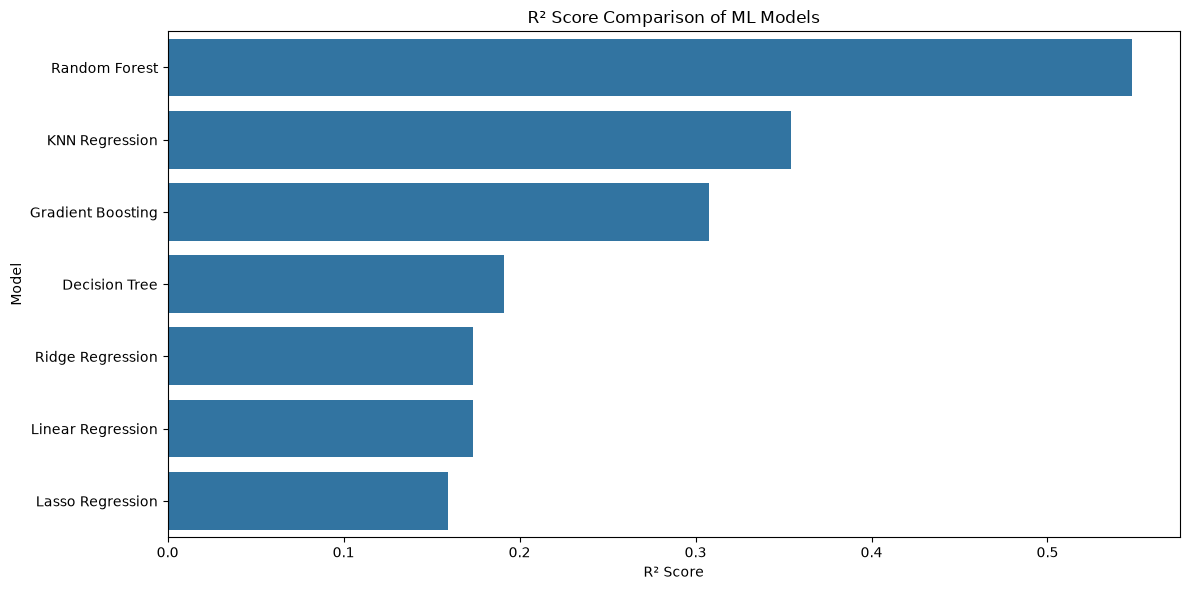

In [58]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="R2 Score",
    y="Model"
)

plt.title("R² Score Comparison of ML Models")
plt.xlabel("R² Score")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

In [59]:
## RMSE Comparison

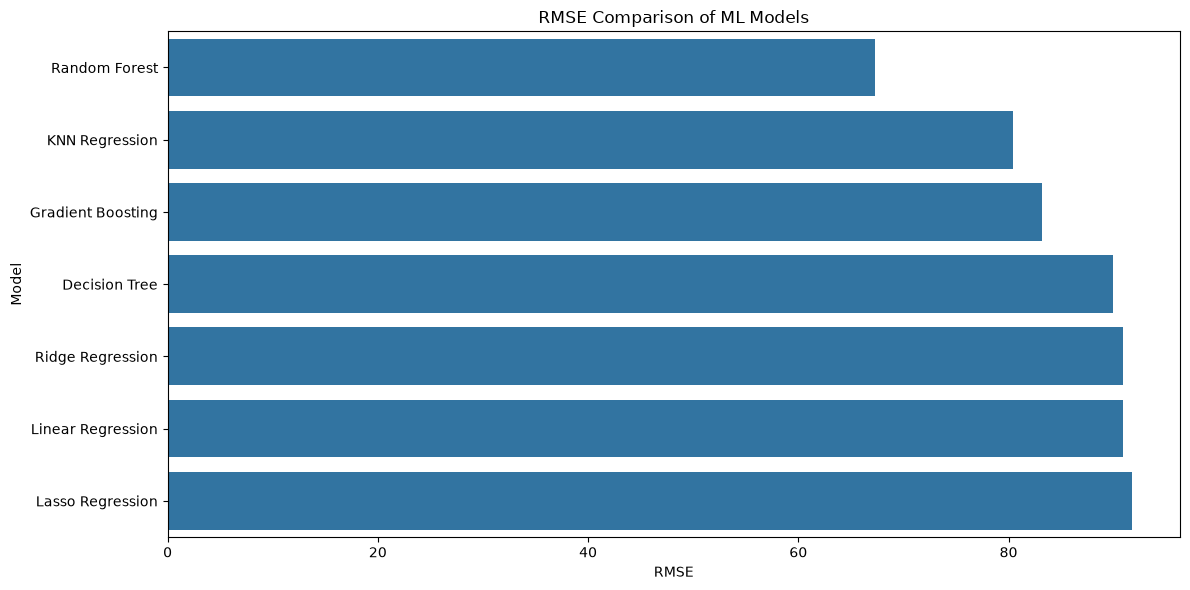

In [60]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model"
)

plt.title("RMSE Comparison of ML Models")
plt.xlabel("RMSE")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

In [61]:
## MAE Comparison

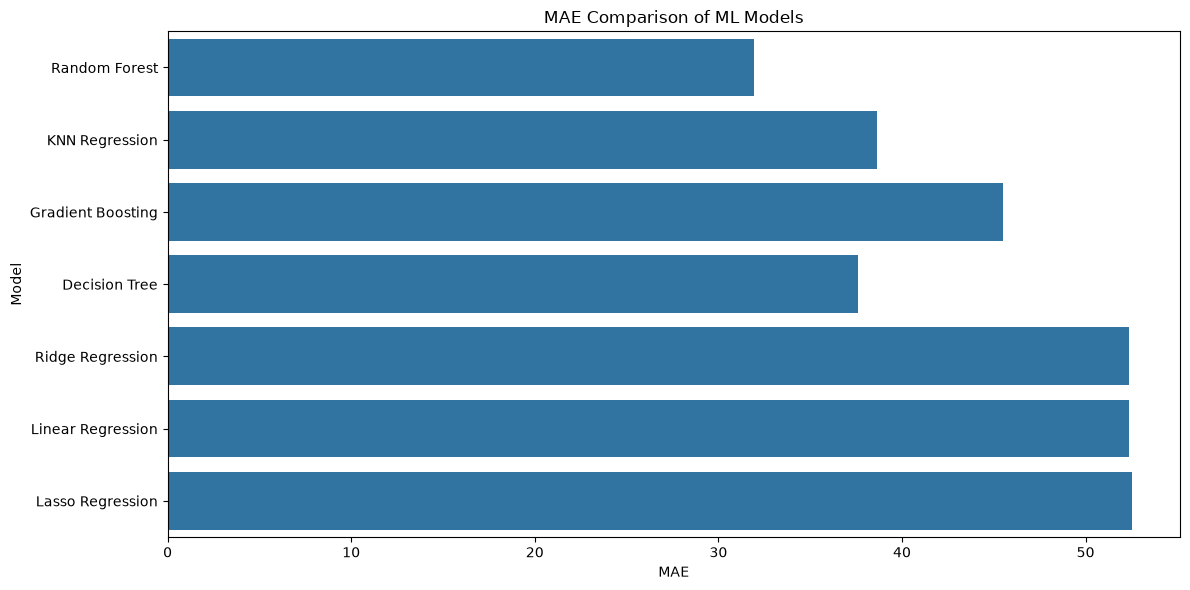

In [62]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="MAE",
    y="Model"
)

plt.title("MAE Comparison of ML Models")
plt.xlabel("MAE")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

In [63]:
# Find Best Model

In [64]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

best_predictions = predictions[
    best_model_name
]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [65]:
## Actual vs Predicted Table

In [66]:
comparison = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": best_predictions

})

print(
    comparison.head(20).to_string(
        index=False
    )
)

 Actual  Predicted
     40       52.2
     90      106.6
     50       45.8
     50       62.8
     70       75.9
    120      125.1
    120      111.3
     70      112.2
     50       51.1
     70       98.0
    110      220.1
     70       68.1
    100      134.0
    110      114.5
    120      213.7
     50       47.3
     50       57.3
     50       51.2
     30       40.1
    140      138.5


In [67]:
## Actual vs Predicted Graph

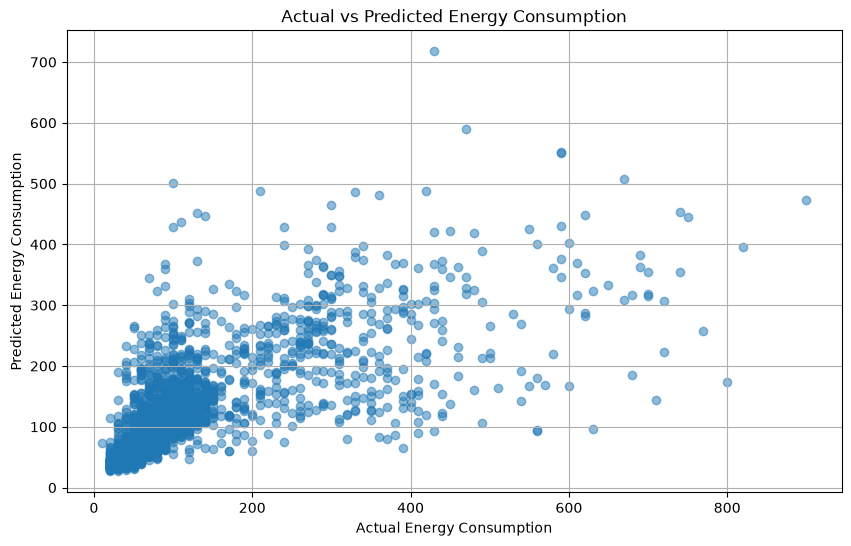

In [68]:
plt.figure(figsize=(10, 6))

plt.scatter(
    comparison["Actual"],
    comparison["Predicted"],
    alpha=0.5
)

plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")

plt.title(
    "Actual vs Predicted Energy Consumption"
)

plt.grid(True)

plt.show()

In [69]:
# Prediction Error

In [70]:
comparison["Error"] = (
    comparison["Actual"]
    - comparison["Predicted"]
)

print(
    comparison.head(20).to_string(
        index=False
    )
)

 Actual  Predicted  Error
     40       52.2  -12.2
     90      106.6  -16.6
     50       45.8    4.2
     50       62.8  -12.8
     70       75.9   -5.9
    120      125.1   -5.1
    120      111.3    8.7
     70      112.2  -42.2
     50       51.1   -1.1
     70       98.0  -28.0
    110      220.1 -110.1
     70       68.1    1.9
    100      134.0  -34.0
    110      114.5   -4.5
    120      213.7  -93.7
     50       47.3    2.7
     50       57.3   -7.3
     50       51.2   -1.2
     30       40.1  -10.1
    140      138.5    1.5


In [71]:
## Error Distribution

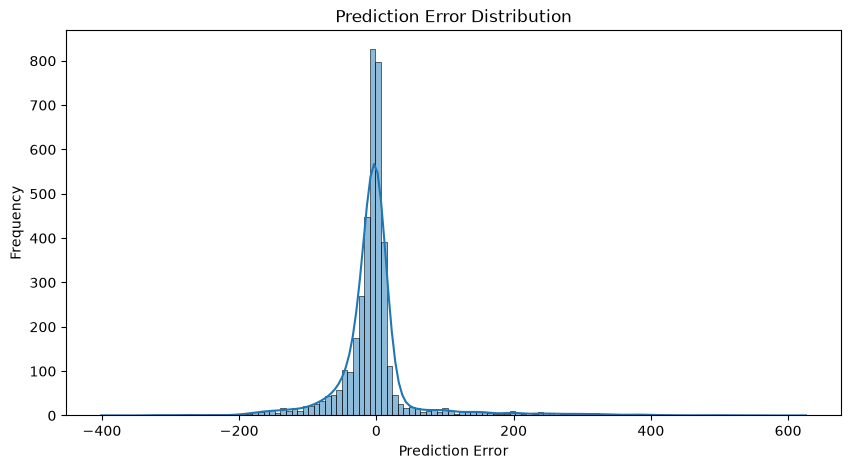

In [72]:
plt.figure(figsize=(10, 5))

sns.histplot(
    comparison["Error"],
    kde=True
)

plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")

plt.show()

In [73]:
## Random Forest Feature Importance

In [74]:
rf_model = trained_models[
    "Random Forest"
]

feature_importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance":
        rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(
    feature_importance.to_string(
        index=False
    )
)

    Feature  Importance
       hour    0.148913
         T3    0.058233
       RH_3    0.043183
       RH_5    0.039218
Press_mm_hg    0.037304
         T8    0.036157
       RH_2    0.035060
       RH_1    0.032085
  Tdewpoint    0.032079
       RH_8    0.029789
       RH_4    0.029569
         T4    0.029440
       RH_7    0.029247
         T2    0.029150
     RH_out    0.029045
     lights    0.028562
       RH_9    0.028526
       RH_6    0.026862
         T7    0.026700
         T6    0.026015
  Windspeed    0.025459
      T_out    0.025039
         T1    0.023768
         T5    0.022377
      month    0.021660
 Visibility    0.021173
        rv2    0.019615
        rv1    0.019035
         T9    0.018552
        day    0.017889
day_of_week    0.007149
 is_evening    0.002433
 is_weekend    0.000715


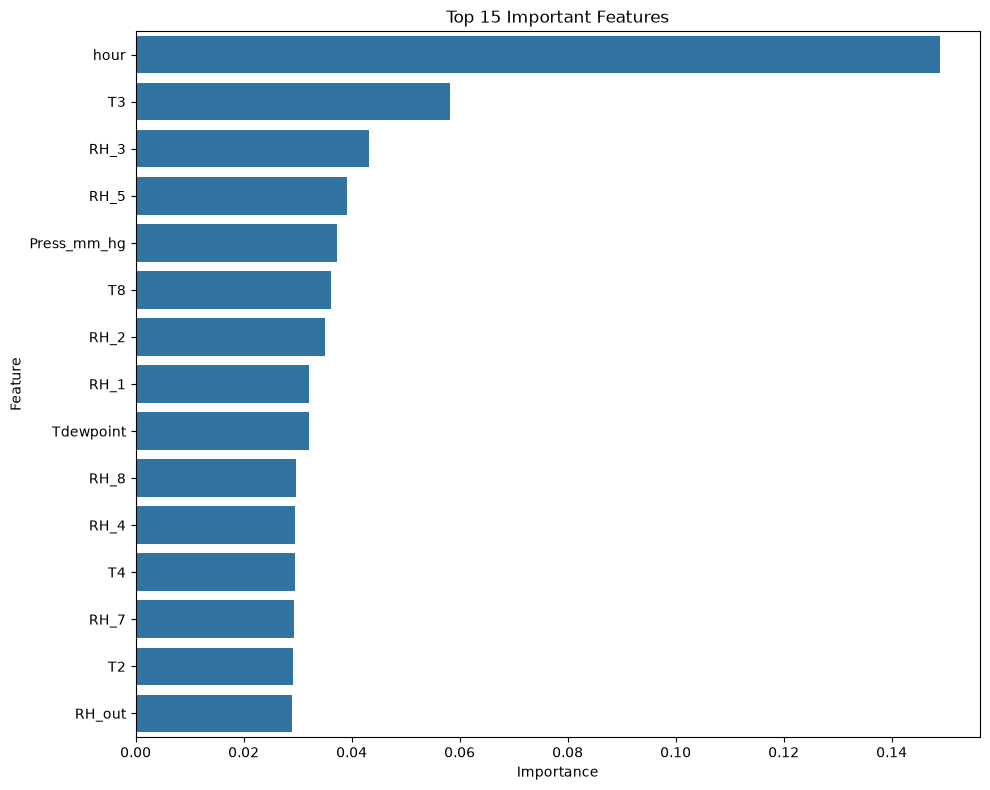

In [75]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [77]:
## Predict One New Observation

In [78]:
sample = X_test.iloc[[0]]

print("Input data:")
print(sample)

Input data:
      lights     T1  RH_1     T2       RH_2     T3  RH_3     T4  RH_4    T5  \
8980       0  20.89  35.4  17.76  39.163333  20.29  36.9  19.76  34.2  18.6   

      ...  Visibility  Tdewpoint        rv1        rv2  hour  day  month  \
8980  ...        63.0        0.0  25.622221  25.622221     1   14      3   

      day_of_week  is_weekend  is_evening  
8980            0           0           0  

[1 rows x 33 columns]


In [79]:
print("\nPredictions from all models:")

for name, model in trained_models.items():

    if name in [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "KNN Regression"
    ]:

        sample_scaled = scaler.transform(
            sample
        )

        prediction = model.predict(
            sample_scaled
        )

    else:

        prediction = model.predict(
            sample
        )

    print(
        name,
        "=>",
        round(prediction[0], 2),
        "Wh"
    )


Predictions from all models:
Linear Regression => 28.26 Wh
Ridge Regression => 28.25 Wh
Lasso Regression => 22.23 Wh
KNN Regression => 48.0 Wh
Decision Tree => 60.0 Wh
Random Forest => 52.2 Wh
Gradient Boosting => 45.69 Wh


In [80]:
## Compare With Actual Value

In [81]:
actual_value = y_test.iloc[0]

print(
    "Actual Energy:",
    actual_value,
    "Wh"
)

print(
    "Best Model Prediction:",
    round(best_predictions[0], 2),
    "Wh"
)

Actual Energy: 40 Wh
Best Model Prediction: 52.2 Wh


In [82]:
# Save Best Model

In [83]:
joblib.dump(
    best_model,
    "best_energy_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


In [84]:
# Save Scaler

In [85]:
joblib.dump(
    scaler,
    "energy_scaler.pkl"
)

print("Scaler saved successfully!")

Scaler saved successfully!


In [86]:
# Save Model Results

In [88]:
results_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


In [89]:
## Final Project Summary

In [90]:
print("=" * 60)
print("SMART HOME ENERGY PREDICTION")
print("=" * 60)

print("Dataset Shape:", df.shape)

print(
    "Number of Features:",
    X.shape[1]
)

print(
    "Number of ML Models:",
    len(models)
)

print(
    "Best Model:",
    best_model_name
)

best_row = results_df.iloc[0]

print(
    "MAE:",
    round(best_row["MAE"], 2)
)

print(
    "RMSE:",
    round(best_row["RMSE"], 2)
)

print(
    "R2 Score:",
    round(best_row["R2 Score"], 4)
)

print("=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 60)

SMART HOME ENERGY PREDICTION
Dataset Shape: (19735, 35)
Number of Features: 33
Number of ML Models: 7
Best Model: Random Forest
MAE: 31.96
RMSE: 67.26
R2 Score: 0.5479
PROJECT COMPLETED SUCCESSFULLY!
